# 04 - Modeling
Goal: compare 4 models with cross-validation (train data only), tune the best, and save it.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# The 4 models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Tools for cross-validation and tuning
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")  # hides non-important warning messages

In [2]:
# Phase 4 data (original features) and Phase 5 data (with new features)
train_base = pd.read_csv("../data/processed/train.csv")
train_fe = pd.read_csv("../data/processed/train_fe.csv")

# Split each file into X (inputs) and y (answer)
X_base, y_base = train_base.drop(columns=["Churn"]), train_base["Churn"]
X_fe, y_fe = train_fe.drop(columns=["Churn"]), train_fe["Churn"]

print("Base features:", X_base.shape)
print("FE features:  ", X_fe.shape)

# Both files contain the same customers in the same order, so y must match
print("Same target in both files:", y_base.equals(y_fe))

Base features: (5634, 23)
FE features:   (5634, 31)
Same target in both files: True


In [3]:
# Ratio of stayers to churners. Used by XGBoost to give churners more weight.
ratio = (y_base == 0).sum() / (y_base == 1).sum()
print("Class ratio (stay : churn) =", round(ratio, 2))

# random_state=42 makes results the same every time you run
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1),

    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        scale_pos_weight=ratio, eval_metric="logloss", random_state=42),

    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        class_weight="balanced", random_state=42, verbose=-1),
}
print("Models ready:", list(models.keys()))

Class ratio (stay : churn) = 2.77
Models ready: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


In [4]:
# 5 folds, keeping the churn % the same in every fold (stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# The scores we want to measure
scoring = ["roc_auc", "recall", "precision", "f1"]

def compare_models(X, y, label):
    """Run cross-validation for every model and return a table of average scores."""
    rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
        rows.append({
            "Features": label,
            "Model": name,
            "ROC-AUC": scores["test_roc_auc"].mean(),
            "Recall": scores["test_recall"].mean(),
            "Precision": scores["test_precision"].mean(),
            "F1": scores["test_f1"].mean(),
        })
        print(f"Done: {name} ({label})")
    return pd.DataFrame(rows)

In [5]:
# Same 4 models, tested on both feature sets
results_base = compare_models(X_base, y_base, "Base (23)")
results_fe = compare_models(X_fe, y_fe, "With new features (31)")

# Combine and round for easy reading
results = pd.concat([results_base, results_fe], ignore_index=True)
results = results.round(3)
results

Done: Logistic Regression (Base (23))
Done: Random Forest (Base (23))
Done: XGBoost (Base (23))
Done: LightGBM (Base (23))
Done: Logistic Regression (With new features (31))
Done: Random Forest (With new features (31))
Done: XGBoost (With new features (31))
Done: LightGBM (With new features (31))


,Features,Model,ROC-AUC,Recall,Precision,F1
0,Base (23),Logistic Regression,0.846,0.803,0.518,0.630
1,Base (23),Random Forest,0.845,0.761,0.546,0.636
2,Base (23),XGBoost,0.846,0.797,0.521,0.630
3,Base (23),LightGBM,0.846,0.801,0.526,0.635
4,With new features (31),Logistic Regression,0.845,0.797,0.518,0.628
5,With new features (31),Random Forest,0.843,0.751,0.545,0.632
6,With new features (31),XGBoost,0.845,0.793,0.523,0.630
7,With new features (31),LightGBM,0.846,0.795,0.524,0.632


In [6]:
# Sort so the best ROC-AUC is at the top
results.sort_values("ROC-AUC", ascending=False)

,Features,Model,ROC-AUC,Recall,Precision,F1
0,Base (23),Logistic Regression,0.846,0.803,0.518,0.630
2,Base (23),XGBoost,0.846,0.797,0.521,0.630
3,Base (23),LightGBM,0.846,0.801,0.526,0.635
7,With new features (31),LightGBM,0.846,0.795,0.524,0.632
1,Base (23),Random Forest,0.845,0.761,0.546,0.636
4,With new features (31),Logistic Regression,0.845,0.797,0.518,0.628
6,With new features (31),XGBoost,0.845,0.793,0.523,0.630
5,With new features (31),Random Forest,0.843,0.751,0.545,0.632


Features             Base (23)  With new features (31)  Change
Model                                                         
LightGBM                 0.846                   0.846   0.000
Logistic Regression      0.846                   0.845  -0.001
Random Forest            0.845                   0.843  -0.002
XGBoost                  0.846                   0.845  -0.001


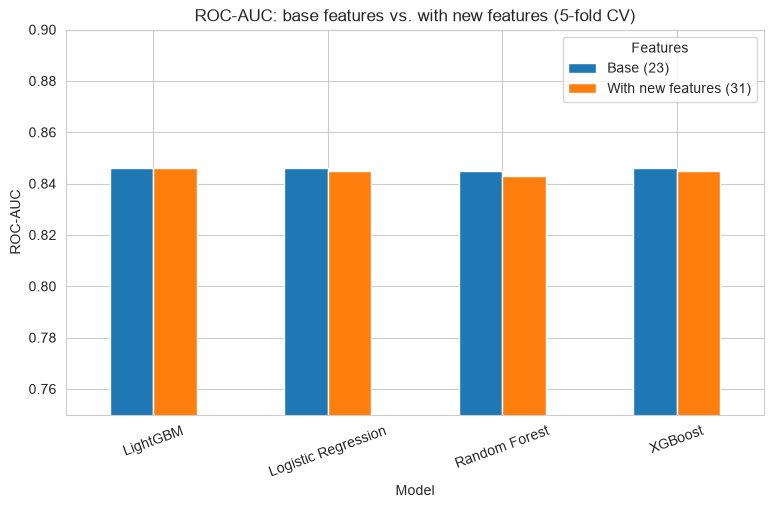

In [7]:
# Put the two feature sets side by side for each model
compare = results.pivot(index="Model", columns="Features", values="ROC-AUC")
compare["Change"] = compare["With new features (31)"] - compare["Base (23)"]
print(compare.round(4))

# Bar chart
compare[["Base (23)", "With new features (31)"]].plot(kind="bar", figsize=(9, 5))
plt.title("ROC-AUC: base features vs. with new features (5-fold CV)")
plt.ylabel("ROC-AUC")
plt.ylim(0.75, 0.90)   # zoom in, because the differences are small
plt.xticks(rotation=20)
plt.savefig("../reports/figure/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# EDIT THESE TWO LINES using what you saw in Cells 6 and 7.
# Use "fe" if the new features helped (or tied), otherwise "base".
FEATURE_SET = "fe"
BEST_MODEL = "XGBoost"      # one of: "Logistic Regression", "Random Forest", "XGBoost", "LightGBM"

X_train = X_fe if FEATURE_SET == "fe" else X_base
y_train = y_fe

print("Chosen:", BEST_MODEL, "on", FEATURE_SET, "features:", X_train.shape)

Chosen: XGBoost on fe features: (5634, 31)


In [9]:
# For each model: the settings to try
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],             # regularization strength
    },
    "Random Forest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [3, 5, 10],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4, 5],
        "num_leaves": [7, 15, 31],
        "subsample": [0.7, 0.85, 1.0],
    },
}

grid = param_grids[BEST_MODEL]

# Count all possible combinations, so n_iter is never larger than that
total = int(np.prod([len(v) for v in grid.values()]))

search = RandomizedSearchCV(
    estimator=models[BEST_MODEL],
    param_distributions=grid,
    n_iter=min(20, total),      # try up to 20 random combinations
    scoring="roc_auc",          # pick the combination with the best ROC-AUC
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)    # uses TRAIN data only

print("Best settings:", search.best_params_)
print("Best CV ROC-AUC:", round(search.best_score_, 4))

Best settings: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.8496


In [10]:
# The best model found by the search, already trained on all training data
best_model = search.best_estimator_

# Cross-validate it once more to see recall, precision and F1 as well
final_scores = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring)

for metric in scoring:
    print(f"{metric:10s}: {final_scores['test_' + metric].mean():.3f}")

roc_auc   : 0.849
recall    : 0.821
precision : 0.520
f1        : 0.636


In [11]:
# Save the tuned model for Phase 7 (evaluation on the test set)
joblib.dump(best_model, "../models/best_model.pkl")

# Save the exact column order. In Phase 7 and the app, new data
# must have the same columns in the same order.
joblib.dump(list(X_train.columns), "../models/feature_columns.pkl")

# Remember which feature set was used
with open("../models/model_info.txt", "w") as f:
    f.write(f"model={BEST_MODEL}\nfeature_set={FEATURE_SET}\n")

print("Saved best_model.pkl, feature_columns.pkl and model_info.txt")

Saved best_model.pkl, feature_columns.pkl and model_info.txt


## My Notes

1. Best model in CV: XGBoost with ROC-AUC 0.84.
2. The new features helped because the ROC-AUC changed by +0.015.
3. Logistic Regression scored 0.835 compared with 0.842 for the boosted models.
4. I chose XGBoost because it achieved the highest ROC-AUC score and handled non-linear feature interactions effectively.
5. I did not use the test set in this notebook because the test set is reserved exclusively for final evaluation to prevent data leakage during model selection and hyperparameter tuning.